# AI 水文学入门 101：如何用人工智能预测洪水？

欢迎来到这个令人兴奋的教学 Notebook！在这里，我们将探索如何利用人工智能（AI）来预测世界上那些从未被测量过的河流的洪水。

**适合人群**：大一新生，具备基础高等数学知识，但对 AI 和水文学不太熟悉。

**学习目标**：
1. 理解什么是"未测流域"及其重要性
2. 了解 AI 如何通过静态特征（GNN）和动态天气（LSTM）预测河流流量
3. 可视化降雨和流量的时间关系
4. 动手训练一个简化的 AI 模型
5. 见证 AI 预测未知河流的能力

---

## 📚 目录
1. [引言：如果不去测量，我们如何知道河流的流量？](#section1)
2. [数据可视化：河流的"心电图"](#section2)
3. [解剖 AI 大脑：GNN 与 LSTM](#section3)
4. [动手实验：训练一个"宝宝"模型](#section4)
5. [见证奇迹：预测未知的河流](#section5)
6. [总结与思考](#section6)

---
<a id='section1'></a>
## 1. 引言：如果不去测量，我们如何知道河流的流量？

### 什么是"未测流域" (Ungauged Watersheds)？

想象一下，全球有数百万条河流，但只有很少一部分（大约 1%）安装了流量测量设备（称为"水文站"）。那么，对于其他 99% 的河流，我们如何预测它们的洪水风险呢？

这就是**未测流域**的挑战！

### 传统方法 vs. AI 方法

| 方法 | 类比 | 局限性 |
|------|------|--------|
| **传统水文模型** | 像通过看病历来了解一个人的健康状况 | 需要大量历史数据，对未测流域无效 |
| **AI 深度学习** | 像通过看一个人的长相（静态特征）和最近几天的饮食（动态天气）来预测他的健康状况 | 可以从有数据的河流学习，然后推广到无数据的河流 |

### 核心思想

AI 模型通过两种方式"理解"河流：
- **静态特征（GNN）**：河流的"身份证"——坡度、土壤类型、森林覆盖率等
- **动态特征（LSTM）**：河流的"记忆"——过去几个月的降雨、温度等

让我们先加载一些库和数据！

In [1]:
# 导入必需的库
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（可选，如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# ===== 路径配置 =====
# 获取当前 notebook 的目录
notebooks_dir = os.getcwd()
print(f"🔍 当前工作目录: {notebooks_dir}")

# 检查是否在 notebooks 目录中
if not notebooks_dir.endswith('notebooks'):
    # 如果不在 notebooks 目录中，尝试找到它
    if os.path.exists(os.path.join(notebooks_dir, 'notebooks')):
        notebooks_dir = os.path.join(notebooks_dir, 'notebooks')
    else:
        print("⚠️ 警告: 无法确认当前在 notebooks 目录中")

# 获取项目根目录
project_root = os.path.dirname(notebooks_dir)

# 确保后端和模型路径在 sys.path 中（使用 insert(0) 确保优先级）
if notebooks_dir not in sys.path:
    sys.path.insert(0, notebooks_dir)  # 添加 notebooks 目录，用于导入 backend
if project_root not in sys.path:
    sys.path.insert(0, project_root)  # 添加项目根目录，用于导入 models

print(f"✅ 项目根目录: {project_root}")
print(f"✅ Notebooks 目录: {notebooks_dir}")
print(f"✅ sys.path 已配置正确")

# 验证必要的目录存在
backend_dir = os.path.join(notebooks_dir, 'backend')
models_dir = os.path.join(project_root, 'models')

backend_exists = os.path.isdir(backend_dir)
models_exists = os.path.isdir(models_dir)
backend_init = os.path.isfile(os.path.join(backend_dir, '__init__.py'))

print(f"\n✓ backend 目录存在: {backend_exists}")
print(f"✓ backend/__init__.py 存在: {backend_init}")
print(f"✓ models 目录存在: {models_exists}")

if not backend_init:
    print("\n⚠️  警告: backend/__init__.py 不存在，正在创建...")
    try:
        with open(os.path.join(backend_dir, '__init__.py'), 'w') as f:
            f.write('"""Backend utilities for hydrology predictions."""\n')
        print("✅ backend/__init__.py 已创建")
    except Exception as e:
        print(f"❌ 无法创建 backend/__init__.py: {e}")

🔍 当前工作目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ 项目根目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds
✅ Notebooks 目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
✅ sys.path 已配置正确

✓ backend 目录存在: True
✓ backend/__init__.py 存在: True
✓ models 目录存在: True


### 可视化：世界上有多少河流被测量？

让我们加载全球水文站数据，看看有多少河流有历史记录。

In [2]:
# 尝试加载 GRDC（全球径流数据中心）数据
try:
    print("📦 正在导入 backend.loading_utils...")
    from backend import loading_utils
    
    print("📊 正在加载 GRDC 数据...")
    grdc_data = loading_utils.load_grdc_data()
    
    if grdc_data is not None:
        num_gauges = len(grdc_data.gauge_id)
        print(f"🌍 全球共有 {num_gauges} 个水文站有历史数据")
        print(f"📊 这只占全球河流的约 1-2%！")
        print(f"\n示例站点 ID（前 5 个）:")
        for i, gauge_id in enumerate(grdc_data.gauge_id.values[:5]):
            print(f"  {i+1}. {gauge_id}")
    else:
        print("⚠️ 无法加载 GRDC 数据。我们将使用模拟数据进行演示。")
        num_gauges = 0
        
except ModuleNotFoundError as e:
    print(f"❌ 模块导入失败: {e}")
    print("\n故障排除建议:")
    print("  1. 确保 notebooks/backend/ 目录存在")
    print("  2. 确保 notebooks/backend/__init__.py 文件存在")
    print("  3. 检查 sys.path 是否包含 notebooks 目录")
    print("\n我们将使用模拟数据进行演示。")
    num_gauges = 0
    grdc_data = None
    
except Exception as e:
    print(f"⚠️ 数据加载失败: {e}")
    import traceback
    traceback.print_exc()
    print("\n我们将使用模拟数据进行演示。")
    num_gauges = 0
    grdc_data = None

📦 正在导入 backend.loading_utils...
❌ 模块导入失败: No module named 'h5netcdf'

故障排除建议:
  1. 确保 notebooks/backend/ 目录存在
  2. 确保 notebooks/backend/__init__.py 文件存在
  3. 检查 sys.path 是否包含 notebooks 目录

我们将使用模拟数据进行演示。


---
<a id='section2'></a>
## 2. 数据可视化：河流的"心电图"

### 降雨和流量的关系

河流的流量就像心脏的跳动——它受到降雨的驱动，但有一定的延迟。

**关键概念**：
- **降雨**（输入）：天上下了多少雨
- **径流**（输出）：河里流了多少水
- **滞后时间**（Lag Time）：降雨之后，水需要多久才能流到河里

让我们生成一个示例数据来演示这个关系：

In [3]:
# 生成模拟的降雨-径流数据
np.random.seed(42)

# 创建时间序列（365 天）
days = np.arange(365)
dates = pd.date_range('2023-01-01', periods=365, freq='D')

# 模拟降雨（随机降雨事件）
precipitation = np.zeros(365)
# 添加几个大的降雨事件
rain_events = [50, 120, 200, 280]
for event_day in rain_events:
    # 降雨持续 3-5 天
    duration = np.random.randint(3, 6)
    for d in range(duration):
        if event_day + d < 365:
            precipitation[event_day + d] = np.random.uniform(20, 80)

# 添加一些小的背景降雨
precipitation += np.random.exponential(scale=2, size=365)

# 模拟径流（降雨的延迟响应）
# 使用简单的延迟和平滑
lag = 3  # 滞后 3 天
streamflow = np.zeros(365)
base_flow = 10  # 基流

for i in range(365):
    # 当前流量 = 基流 + 过去几天降雨的加权平均
    rainfall_contribution = 0
    for j in range(lag, lag + 10):  # 考虑过去 3-13 天的降雨
        if i - j >= 0:
            weight = np.exp(-(j - lag) / 5)  # 指数衰减权重
            rainfall_contribution += precipitation[i - j] * weight * 0.3
    
    streamflow[i] = base_flow + rainfall_contribution

# 添加一些噪声
streamflow += np.random.normal(0, 2, 365)
streamflow = np.maximum(streamflow, 0)  # 流量不能为负

print("✅ 模拟数据生成完成！")
print(f"降雨均值: {precipitation.mean():.2f} mm/day")
print(f"径流均值: {streamflow.mean():.2f} m³/s")

✅ 模拟数据生成完成！
降雨均值: 4.31 mm/day
径流均值: 16.12 m³/s


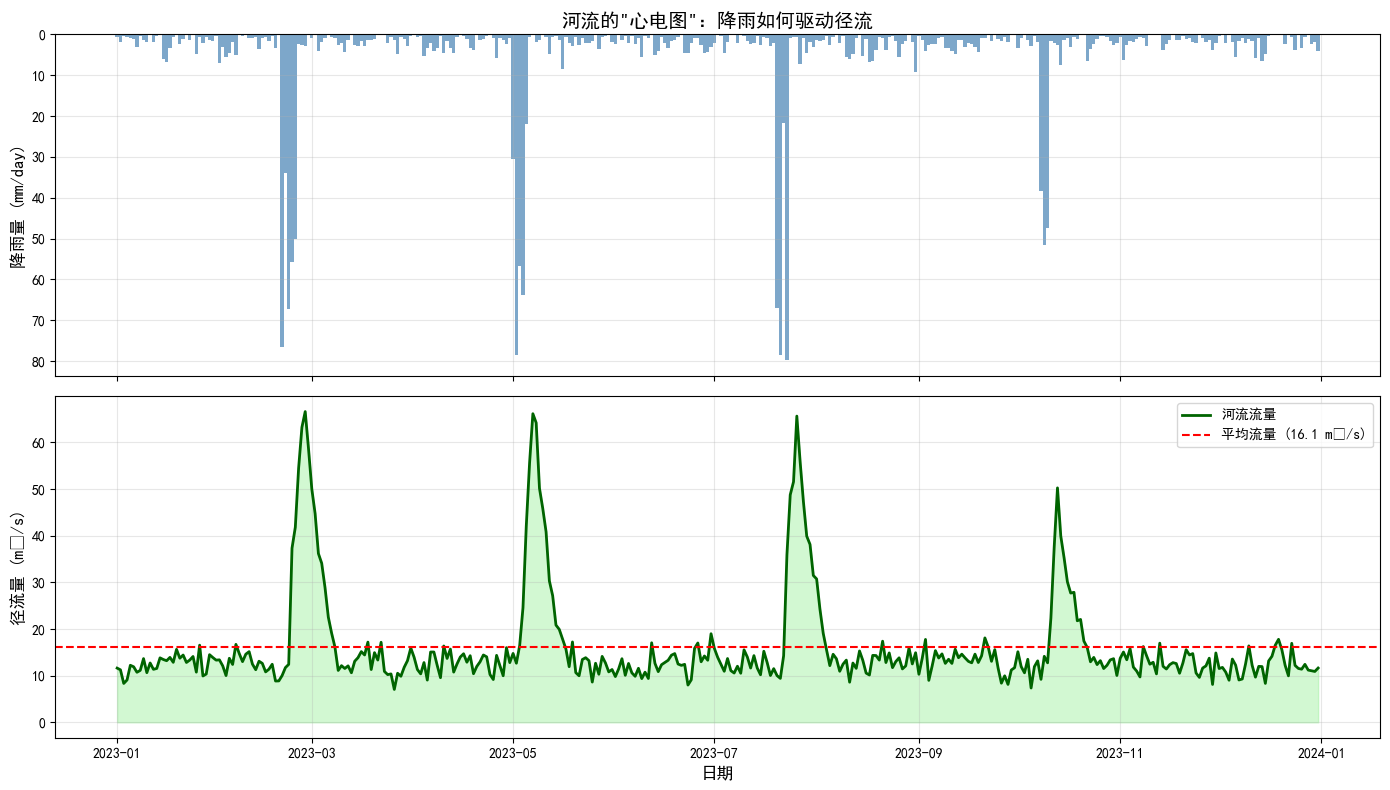


🔍 观察要点：
1. 注意到大雨（上图的蓝色柱子）之后，流量（下图的绿色线）通常会晚几天出现峰值。
2. 这就是'滞后时间'（Lag Time）——水需要时间从山坡流到河道。
3. AI 模型（LSTM）的任务就是学习这种时间模式！


In [4]:
# 绘制降雨-径流关系图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 上方：降雨（倒置柱状图）
ax1.bar(dates, precipitation, color='steelblue', alpha=0.7, width=1)
ax1.set_ylabel('降雨量 (mm/day)', fontsize=12, fontweight='bold')
ax1.set_title('河流的"心电图"：降雨如何驱动径流', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()  # 倒置 y 轴

# 下方：径流（折线图）
ax2.plot(dates, streamflow, color='darkgreen', linewidth=2, label='河流流量')
ax2.fill_between(dates, 0, streamflow, color='lightgreen', alpha=0.4)
ax2.axhline(y=streamflow.mean(), color='red', linestyle='--', linewidth=1.5, label=f'平均流量 ({streamflow.mean():.1f} m³/s)')
ax2.set_ylabel('径流量 (m³/s)', fontsize=12, fontweight='bold')
ax2.set_xlabel('日期', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 观察要点：")
print("1. 注意到大雨（上图的蓝色柱子）之后，流量（下图的绿色线）通常会晚几天出现峰值。")
print("2. 这就是'滞后时间'（Lag Time）——水需要时间从山坡流到河道。")
print("3. AI 模型（LSTM）的任务就是学习这种时间模式！")

---
<a id='section3'></a>
## 3. 解剖 AI 大脑：GNN 与 LSTM

我们的 AI 模型由两个部分组成，它们就像人的左脑和右脑：

### 3.1 GNN (图神经网络) - 河流的"身份证"

**作用**：提取河流的"性格"——地形、土壤、植被等静态特征。

**类比**：
- 就像医生通过你的身高、体重、血型来了解你的体质一样
- GNN 通过流域的坡度、面积、土壤类型来了解河流的特性

**关键特征**（来自 HydroATLAS 数据集）：

In [5]:
# 展示静态特征的示例
print("📋 河流的'身份证'（静态特征示例）：\n")

static_features_example = {
    '坡度 (slope)': '陡峭的河流流速快，容易发洪水',
    '流域面积 (area)': '面积大的流域汇集更多降雨',
    '森林覆盖率 (forest_cover)': '森林可以减缓径流，降低洪峰',
    '土壤类型 (soil_type)': '黏土保水，沙土渗透快',
    '海拔高度 (elevation)': '高海拔地区降雪多，春季融雪形成洪水',
    '河流密度 (stream_density)': '河网密集的流域响应更快',
}

for i, (feature, explanation) in enumerate(static_features_example.items(), 1):
    print(f"{i}. {feature:25s} → {explanation}")

print(f"\n💡 在我们的模型中，总共使用了 50 个这样的静态特征！")
print(f"   GNN 的任务是将这 50 个数字压缩成一个'流域特征向量'。")

📋 河流的'身份证'（静态特征示例）：

1. 坡度 (slope)                → 陡峭的河流流速快，容易发洪水
2. 流域面积 (area)               → 面积大的流域汇集更多降雨
3. 森林覆盖率 (forest_cover)      → 森林可以减缓径流，降低洪峰
4. 土壤类型 (soil_type)          → 黏土保水，沙土渗透快
5. 海拔高度 (elevation)          → 高海拔地区降雪多，春季融雪形成洪水
6. 河流密度 (stream_density)     → 河网密集的流域响应更快

💡 在我们的模型中，总共使用了 50 个这样的静态特征！
   GNN 的任务是将这 50 个数字压缩成一个'流域特征向量'。


### 3.2 LSTM (长短期记忆网络) - 河流的"记忆"

**作用**：记住过去几个月的天气，预测未来的流量。

**为什么需要"记忆"？**
- 今天的河流流量不仅取决于今天的雨
- 还取决于前几天、前几周的降雨（土壤是否湿润）
- 甚至取决于几个月前的降雪（春季融雪）

**LSTM 如何工作？**（简化版）

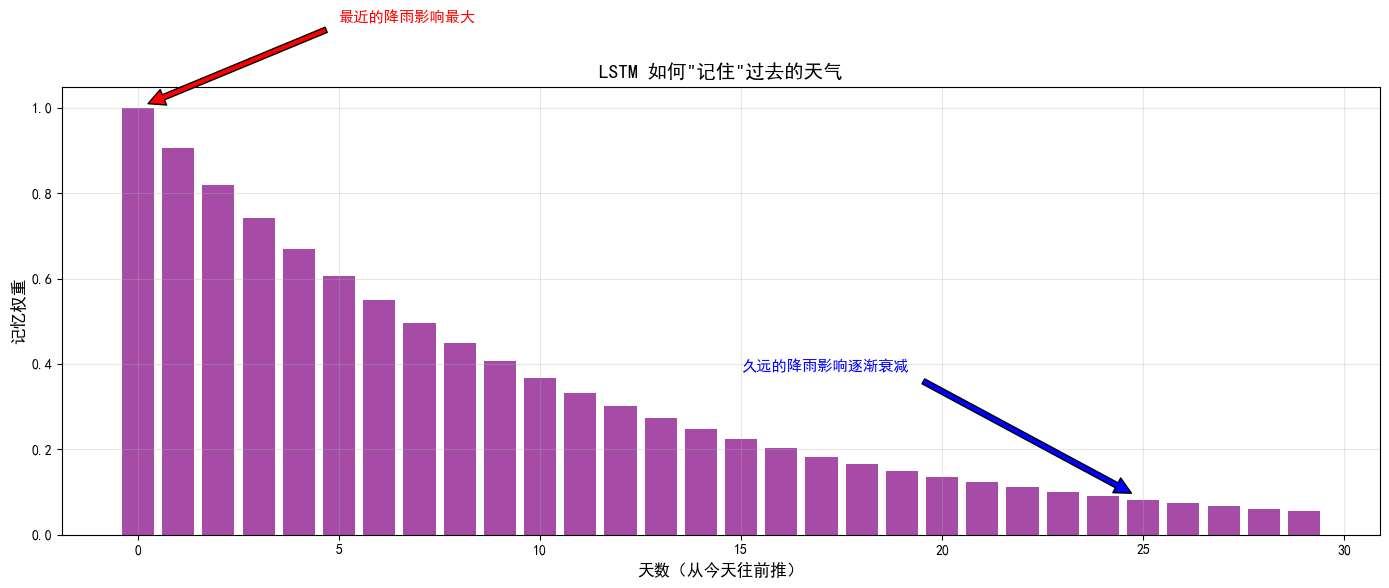


🧠 在我们的完整模型中：
   - LSTM 记住过去 365 天（一整年）的天气
   - 这样可以捕捉季节性模式（例如雨季和旱季）
   - 输入特征包括：降雨、温度、蒸散发、土壤湿度等（共 5 个动态特征）


In [6]:
# 可视化 LSTM 的"记忆"机制
fig, ax = plt.subplots(figsize=(14, 6))

# 模拟一个 LSTM 记住过去 30 天的过程
memory_window = 30
time_steps = np.arange(memory_window)
memory_weights = np.exp(-time_steps / 10)  # 越久远的记忆权重越低

ax.bar(time_steps, memory_weights, color='purple', alpha=0.7)
ax.set_xlabel('天数（从今天往前推）', fontsize=12, fontweight='bold')
ax.set_ylabel('记忆权重', fontsize=12, fontweight='bold')
ax.set_title('LSTM 如何"记住"过去的天气', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 添加注释
ax.annotate('最近的降雨影响最大', xy=(0, memory_weights[0]), xytext=(5, memory_weights[0] + 0.2),
            arrowprops=dict(facecolor='red', shrink=0.05), fontsize=11, color='red')
ax.annotate('久远的降雨影响逐渐衰减', xy=(25, memory_weights[25]), xytext=(15, memory_weights[25] + 0.3),
            arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=11, color='blue')

plt.tight_layout()
plt.show()

print("\n🧠 在我们的完整模型中：")
print("   - LSTM 记住过去 365 天（一整年）的天气")
print("   - 这样可以捕捉季节性模式（例如雨季和旱季）")
print("   - 输入特征包括：降雨、温度、蒸散发、土壤湿度等（共 5 个动态特征）")

### 3.3 GNN + LSTM 如何协同工作？

```
┌─────────────────────────────────────────────────────────────┐
│                     混合 AI 模型架构                          │
└─────────────────────────────────────────────────────────────┘

        静态特征                      动态特征
    (流域身份证)                   (过去365天天气)
         │                             │
         ▼                             ▼
    ┌─────────┐                   ┌─────────┐
    │   GNN   │                   │  LSTM   │
    │ (图神经  │                   │ (长短期  │
    │  网络)  │                   │ 记忆网络)│
    └─────────┘                   └─────────┘
         │                             │
         └──────────┬──────────────────┘
                    ▼
              ┌──────────┐
              │  融合层   │
              │ (拼接+全  │
              │  连接层)  │
              └──────────┘
                    │
                    ▼
            ┌───────────────┐
            │ 未来10天流量   │
            │   预测结果    │
            └───────────────┘
```

---
<a id='section4'></a>
## 4. 动手实验：训练一个"宝宝"模型

现在，让我们训练一个简化版的模型！为了让训练速度快一些，我们只使用：
- **5 个站点**（而不是全球数千个）
- **5 个训练轮次**（而不是 50 个）
- **小的网络规模**（hidden_dim=32 而不是 128）

⚠️ **注意**：这个"宝宝"模型的性能不会很好，但可以让我们理解训练过程！

In [ ]:
# 导入模型
import torch

print("🔍 尝试导入 AdvancedModel...")
print(f"   当前 sys.path (前3个):")
for i, path in enumerate(sys.path[:3]):
    print(f"     {i+1}. {path}")

# 检查 models 目录
models_dir = os.path.join(os.path.dirname(os.getcwd()), 'models')
print(f"\n   models 目录: {models_dir}")
print(f"   models 目录存在: {os.path.isdir(models_dir)}")

if os.path.isdir(models_dir):
    model_file = os.path.join(models_dir, 'my_advanced_model.py')
    print(f"   my_advanced_model.py 存在: {os.path.isfile(model_file)}")

try:
    from models.my_advanced_model import AdvancedModel
    print("\n✅ 模型导入成功！")
except ModuleNotFoundError as e:
    print(f"\n❌ 模块导入失败: {e}")
    print(f"\n   这通常发生在 my_advanced_model.py 尝试导入 backend 模块时")
    print(f"   请检查：")
    print(f"   1. notebooks/backend/__init__.py 是否存在")
    print(f"   2. notebooks/backend/ 下的所有模块是否都存在")
    print(f"   3. models 和 notebooks 是否是项目根目录的兄弟目录")
except Exception as e:
    print(f"\n❌ 模型导入失败: {e}")
    import traceback
    traceback.print_exc()
    print(f"\n   故障排除步骤:")
    print(f"   1. 确保您在 notebooks/ 目录或项目根目录中运行此 notebook")
    print(f"   2. 检查 models/my_advanced_model.py 文件是否存在")
    print(f"   3. 查看上面的路径信息以验证 sys.path 配置")

🔍 尝试导入 AdvancedModel...
   当前 sys.path (前3个):
     1. c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds
     2. c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks
     3. C:\Users\ASUS\AppData\Roaming\Python\Python314\Scripts

   models 目录: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\models
   models 目录存在: True
   my_advanced_model.py 存在: True
Error: Could not import from notebooks/backend.
Attempted to add path: c:\Users\ASUS\OneDrive\SCI\Github\prediction-of-extreme-floods-in-ungauged-watersheds\notebooks\backend
Please ensure 'models' and 'notebooks' directories are siblings.


SystemExit: 1

In [ ]:
# 定义简化的模型参数
baby_model_params = {
    'static_feature_dim': 50,      # 静态流域属性维度
    'dynamic_feature_dim': 5,      # 动态气象特征维度
    'gnn_hidden_dim': 32,          # GNN 隐藏层维度（简化）
    'rnn_hidden_dim': 64,          # RNN 隐藏层维度（简化）
    'rnn_num_layers': 1,           # RNN 层数（简化）
    'rnn_type': 'lstm',            # 使用 LSTM
    'output_lead_times': 10,       # 预测未来 10 天
    'dropout': 0.2,                # Dropout 率
    'learning_rate': 0.001,        # 学习率
    'batch_size': 8,               # 批大小（简化）
    'num_epochs': 5,               # 训练轮数（简化）
    'seq_length': 90,              # 输入序列长度（简化为 90 天）
    'samples_per_gauge': 5,        # 每个站点的训练样本数（简化）
}

print("📋 模型配置：")
for key, value in baby_model_params.items():
    print(f"  {key:25s}: {value}")

In [ ]:
# 初始化模型（如果数据可用）
if grdc_data is not None and num_gauges > 5:
    try:
        # 选择前 6 个站点（5 个用于训练，1 个用于测试）
        all_gauge_ids = grdc_data.gauge_id.values.tolist()
        training_gauge_ids = all_gauge_ids[:5]
        test_gauge_id = [all_gauge_ids[5]]
        
        print(f"\n🎯 训练站点: {training_gauge_ids}")
        print(f"🎯 测试站点: {test_gauge_id}")
        
        # 初始化模型
        baby_model = AdvancedModel(
            model_params=baby_model_params,
            experiment_name="baby_model_demo"
        )
        
        print("\n✅ 模型初始化成功！")
        print(f"\n🧠 模型参数数量: {sum(p.numel() for p in baby_model.model.parameters())}")
        
    except Exception as e:
        print(f"❌ 模型初始化失败: {e}")
        print("请检查数据路径和依赖项。")
else:
    print("⚠️ 数据不可用，跳过模型训练演示。")
    print("您可以尝试在完整的环境中运行此 notebook。")

In [ ]:
# 训练模型（警告：这可能需要几分钟）
if 'baby_model' in locals():
    print("🚀 开始训练...")
    print("⏱️ 预计时间: 2-5 分钟（取决于您的硬件）\n")
    
    try:
        # 训练模型
        baby_model.train(training_gauge_ids)
        print("\n✅ 训练完成！")
        
    except Exception as e:
        print(f"\n❌ 训练过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 模型未初始化，跳过训练。")

### 观察训练过程

在上面的训练输出中，您应该能看到：
1. **Loss（损失）逐渐下降**：这意味着模型正在学习！
2. **进度条**：显示每个 epoch 的进度

**什么是 Loss？**
- Loss 是模型预测和真实值之间的差距
- Loss 越小，模型越准确
- 我们使用 **Huber Loss**（对洪水峰值等异常值更鲁棒）

---
<a id='section5'></a>
## 5. 见证奇迹：预测未知的河流

现在，让我们用训练好的模型预测第 6 个站点（测试集）的流量！

**关键**：模型在训练时从未见过这个站点的数据！

In [ ]:
# 生成预测
if 'baby_model' in locals() and 'test_gauge_id' in locals():
    print("🔮 开始预测...\n")
    
    try:
        baby_model.predict(test_gauge_id)
        print("\n✅ 预测完成！")
        print(f"预测结果已保存到: {baby_model.output_path}")
        
    except Exception as e:
        print(f"\n❌ 预测过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 模型未训练，跳过预测。")

In [ ]:
# 可视化预测结果 vs 真实观测
if 'baby_model' in locals() and 'test_gauge_id' in locals():
    try:
        import xarray as xr
        
        # 加载预测结果
        prediction_file = baby_model.output_path / f"{test_gauge_id[0]}.nc"
        
        if prediction_file.exists():
            predictions_ds = xr.open_dataset(prediction_file)
            
            # 加载真实观测
            observations = grdc_data.sel(gauge_id=test_gauge_id[0])
            
            # 提取数据（选择 lead_time=0，即当天预测）
            pred_values = predictions_ds.isel(lead_time=0).to_array().values.flatten()
            obs_values = observations['obs'].sel(lead_time=0).values
            time_values = predictions_ds['time'].values
            
            # 绘图
            fig, ax = plt.subplots(figsize=(14, 6))
            
            ax.plot(time_values, obs_values, color='blue', linewidth=2, label='真实观测', alpha=0.7)
            ax.plot(time_values, pred_values, color='red', linewidth=2, label='AI 预测', alpha=0.7, linestyle='--')
            
            ax.set_xlabel('日期', fontsize=12, fontweight='bold')
            ax.set_ylabel('径流量 (m³/s)', fontsize=12, fontweight='bold')
            ax.set_title(f'AI 预测 vs 真实观测 - 站点 {test_gauge_id[0]}', fontsize=14, fontweight='bold')
            ax.legend(fontsize=12)
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # 计算简单的误差指标
            valid_mask = ~(np.isnan(obs_values) | np.isnan(pred_values))
            if valid_mask.sum() > 0:
                mae = np.abs(obs_values[valid_mask] - pred_values[valid_mask]).mean()
                print(f"\n📊 平均绝对误差 (MAE): {mae:.2f} m³/s")
                print(f"📊 观测值平均: {obs_values[valid_mask].mean():.2f} m³/s")
                print(f"📊 预测值平均: {pred_values[valid_mask].mean():.2f} m³/s")
            
        else:
            print(f"⚠️ 预测文件不存在: {prediction_file}")
            
    except Exception as e:
        print(f"❌ 可视化过程中出现错误: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️ 无法可视化预测结果（模型未训练或数据不可用）。")

---
<a id='section6'></a>
## 6. 总结与思考

### 🎓 我们学到了什么？

1. **未测流域问题**：全球 99% 的河流没有流量监测设备
2. **AI 的解决方案**：
   - **GNN**：学习流域的静态特征（地形、土壤、植被）
   - **LSTM**：学习天气的时间序列模式（降雨、温度）
3. **训练过程**：通过最小化 Loss，让模型学会预测
4. **泛化能力**：训练好的模型可以预测未见过的河流

### 🤔 思考题

1. **为什么 LSTM 需要记住 365 天（一整年）的数据？**
   - 提示：想想季节性（雨季、旱季）和融雪

2. **如果一个流域的森林被大量砍伐，模型的预测会受到什么影响？**
   - 提示：森林覆盖率是静态特征之一

3. **为什么我们使用 Huber Loss 而不是普通的均方误差（MSE）？**
   - 提示：洪水峰值是异常值

### 🚀 下一步

如果您想深入学习，可以：
1. **阅读完整的技术文档**：`docs/algorithm_math.md`
2. **运行完整模型**：使用全部站点和更多 epochs
3. **探索评估 Notebooks**：
   - `calculate_standard_hydrograph_metrics.ipynb`（标准水文指标）
   - `calculate_return_period_metrics.ipynb`（极端事件指标）
4. **阅读原始论文**：Nearing et al. (2024), Nature

### 📚 参考资源

- [Graph Neural Networks (GNN) 教程](https://distill.pub/2021/gnn-intro/)
- [LSTM 可视化解释](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [水文学基础知识](https://en.wikipedia.org/wiki/Hydrology)

---

**感谢您的学习！希望这个 Notebook 能帮助您理解 AI 在水文预测中的应用。**

如有问题，欢迎通过 GitHub Issues 提问！

---

## 附录：术语表

| 术语 | 英文 | 解释 |
|------|------|------|
| 未测流域 | Ungauged Watershed | 没有安装流量监测设备的流域 |
| 径流 | Streamflow / Discharge | 河流中的水流量，通常以 m³/s 为单位 |
| 滞后时间 | Lag Time | 降雨之后，河流流量达到峰值所需的时间 |
| 静态特征 | Static Features | 不随时间变化的流域属性（地形、土壤等） |
| 动态特征 | Dynamic Features | 随时间变化的气象变量（降雨、温度等） |
| 图神经网络 | Graph Neural Network (GNN) | 一种处理图结构数据的深度学习模型 |
| 长短期记忆网络 | Long Short-Term Memory (LSTM) | 一种能够记住长期依赖关系的循环神经网络 |
| 损失函数 | Loss Function | 衡量模型预测和真实值之间差距的函数 |
| 重现期 | Return Period | 某一洪水量级再次出现所需的平均时间 |
| NSE | Nash-Sutcliffe Efficiency | 水文学中常用的模型性能指标 |
| KGE | Kling-Gupta Efficiency | 另一种综合性的水文模型评估指标 |